In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    roc_auc_score,
)

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

RAW_PATH = "WISDM_ar_v1.1_raw.txt"


In [11]:
def load_wisdm_data(path):
    rows = []
    with open(path, "r") as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("user"):
                continue

            if line.endswith(";"):
                line = line[:-1]

            parts = line.split(",")
            if len(parts) < 6:
                continue

            user, activity, ts, x, y, z = parts[:6]
            try:
                rows.append(
                    {
                        "User": int(user),
                        "Activity": activity,
                        "Timestamp": int(ts),
                        "AccX": float(x),
                        "AccY": float(y),
                        "AccZ": float(z),
                    }
                )
            except Exception:
                continue

    return pd.DataFrame(rows)


print("Loading raw WISDM data...")
df = load_wisdm_data(RAW_PATH)
print("Raw shape:", df.shape)

# Basic cleaning similar to your Assignment 5.1
import time
current_ms = int(time.time() * 1000)

df = df[(df["Timestamp"] >0) & (df["Timestamp"] <= current_ms)].copy()

df = df.sort_values("Timestamp").reset_index(drop=True)
df.drop_duplicates(inplace=True)

df.rename(columns={"User": "UserID", "Activity": "ActivityLabel"}, inplace=True)
df_clean = df.reset_index(drop=True)

print("Cleaned shape:", df_clean.shape)
df_clean.head()

Loading raw WISDM data...
Raw shape: (1098198, 6)
Cleaned shape: (214629, 6)


,UserID,ActivityLabel,Timestamp,AccX,AccY,AccZ
0,35,Standing,73452342000,2.03,9.47,2.91
1,35,Standing,73502330000,2.15,9.30,2.83
2,35,Standing,73552348000,2.22,9.38,2.83
3,35,Standing,73602336000,2.37,9.34,3.02
4,35,Standing,73652324000,2.30,9.28,2.83


In [12]:
def extract_window_features(window_df, sampling_rate_hz=20.0):
    """
    Compute statistical, temporal, and frequency-domain features
    for one window of accelerometer data.
    """
    feats = {}

    axes = ["AccX", "AccY", "AccZ"]
    mag = np.sqrt(
        window_df["AccX"].values**2 +
        window_df["AccY"].values**2 +
        window_df["AccZ"].values**2
    )
    window_df = window_df.copy()
    window_df["Mag"] = mag
    axes_with_mag = axes + ["Mag"]

    def basic_stats(x, prefix):
        x = np.asarray(x)
        feats[f"{prefix}_mean"] = float(np.mean(x))
        feats[f"{prefix}_median"] = float(np.median(x))
        feats[f"{prefix}_std"] = float(np.std(x, ddof=1)) if len(x) > 1 else 0.0
        feats[f"{prefix}_var"] = float(np.var(x, ddof=1)) if len(x) > 1 else 0.0
        feats[f"{prefix}_min"] = float(np.min(x))
        feats[f"{prefix}_max"] = float(np.max(x))

        s = pd.Series(x)
        feats[f"{prefix}_skew"] = float(s.skew()) if len(x) > 2 else 0.0
        feats[f"{prefix}_kurtosis"] = float(s.kurtosis()) if len(x) > 3 else 0.0

    for ax in axes_with_mag:
        x = window_df[ax].values
        prefix = ax.lower()

        # 1) Statistical
        basic_stats(x, prefix)

        # 2) Temporal
        feats[f"{prefix}_zcr"] = float(np.mean(np.diff(np.sign(x)) != 0)) if len(x) > 1 else 0.0
        feats[f"{prefix}_energy"] = float(np.sum(x**2))
        feats[f"{prefix}_sma"] = float(np.sum(np.abs(x)) / len(x)) if len(x) > 0 else 0.0
        feats[f"{prefix}_ptp"] = float(np.ptp(x)) if len(x) > 0 else 0.0

        # 3) Frequency domain
        if len(x) > 1:
            fft_vals = np.fft.rfft(x)
            fft_mag = np.abs(fft_vals)
            psd = fft_mag**2

            if psd.sum() == 0:
                centroid = 0.0
                spec_entropy = 0.0
                dom_freq = 0.0
            else:
                freqs = np.fft.rfftfreq(len(x), d=1.0 / sampling_rate_hz)
                centroid = float((freqs * psd).sum() / psd.sum())
                p = psd / psd.sum()
                spec_entropy = float(-(p * np.log2(p + 1e-12)).sum())
                dom_freq = float(freqs[np.argmax(psd)])
        else:
            centroid = spec_entropy = dom_freq = 0.0

        feats[f"{prefix}_spectral_centroid"] = centroid
        feats[f"{prefix}_spectral_entropy"] = spec_entropy
        feats[f"{prefix}_dominant_freq"] = dom_freq

    activity_counts = Counter(window_df["ActivityLabel"])
    feats["ActivityLabel"] = activity_counts.most_common(1)[0][0]

    # Majority user (not used for training, but good for analysis)
    user_counts = Counter(window_df["UserID"])
    feats["UserID"] = user_counts.most_common(1)[0][0]

    return feats


def create_feature_windows(df, window_size=128, step_size=64, sampling_rate_hz=20.0):
    """
    Sliding window segmentation with overlap:
    - window_size: 128 samples (~2.5 seconds @ 20 Hz)
    - step_size : 64 samples (50% overlap)
    """
    features = []
    n = len(df)

    for start in range(0, n - window_size + 1, step_size):
        end = start + window_size
        w = df.iloc[start:end]
        feats = extract_window_features(w, sampling_rate_hz=sampling_rate_hz)
        features.append(feats)

    return pd.DataFrame(features)


print("Creating sliding-window features...")
features_df = create_feature_windows(
    df_clean, window_size=128, step_size=64, sampling_rate_hz=20.0
)
print("Features shape:", features_df.shape)
features_df.head()

Creating sliding-window features...
Features shape: (3352, 62)


,accx_mean,accx_median,accx_std,accx_var,accx_min,accx_max,accx_skew,accx_kurtosis,accx_zcr,accx_energy,...,mag_kurtosis,mag_zcr,mag_energy,mag_sma,mag_ptp,mag_spectral_centroid,mag_spectral_entropy,mag_dominant_freq,ActivityLabel,UserID
0,2.363516,2.37,0.083474,0.006968,2.03,2.53,-0.445747,1.542949,0.0,715.9193,...,-0.128470,0.0,12977.9891,10.069198,0.211495,0.000045,0.000210,0.0,Standing,35
1,2.434922,2.37,0.151059,0.022819,2.22,2.87,1.253609,0.953728,0.0,761.7901,...,2.299169,0.0,12970.1968,10.066142,0.359494,0.000068,0.000280,0.0,Standing,35
2,2.556328,2.60,0.148858,0.022159,2.22,2.87,-0.226358,-0.538863,0.0,839.2703,...,4.162439,0.0,12986.4292,10.072458,0.359494,0.000057,0.000241,0.0,Standing,35
3,2.565000,2.56,0.084583,0.007154,2.37,2.79,0.305546,-0.085392,0.0,843.0494,...,0.174326,0.0,12996.5709,10.076443,0.173881,0.000027,0.000120,0.0,Standing,35
4,2.532578,2.53,0.075130,0.005644,2.37,2.83,0.827771,1.957979,0.0,821.7027,...,0.820068,0.0,13010.1292,10.081681,0.211645,0.000037,0.000159,0.0,Standing,35


In [13]:
X = features_df.drop(columns=["ActivityLabel", "UserID"])
y = features_df["ActivityLabel"]

le = LabelEncoder()
y_enc = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=42, stratify=y_enc
)

models = {}

# 1) Logistic Regression
models["LogisticRegression"] = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=1000, multi_class="multinomial")),
    ]
)

# 2) SVM (RBF)
models["SVM"] = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("clf", SVC(kernel="rbf", probability=True)),
    ]
)

# 3) Random Forest
models["RandomForest"] = RandomForestClassifier(
    n_estimators=200, random_state=42, n_jobs=-1
)

# 4) k-NN
models["kNN"] = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("clf", KNeighborsClassifier(n_neighbors=5)),
    ]
)

metrics_summary = {}

for name, model in models.items():
    print(f"\nTraining model: {name}")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_test, y_pred, average="macro", zero_division=0
    )

    try:
        if hasattr(model, "predict_proba"):
            y_score = model.predict_proba(X_test)
        else:
            if hasattr(model, "decision_function"):
                y_score = model.decision_function(X_test)
            else:
                y_score = None

        if y_score is not None:
            y_test_bin = label_binarize(y_test, classes=np.arange(len(le.classes_)))
            auc = roc_auc_score(y_test_bin, y_score, average="macro", multi_class="ovr")
        else:
            auc = float("nan")
    except Exception:
        auc = float("nan")

    metrics_summary[name] = {
        "accuracy": acc,
        "precision_macro": prec,
        "recall_macro": rec,
        "f1_macro": f1,
        "roc_auc_macro": auc,
    }

    print(
        f"{name}: "
        f"Accuracy = {acc:.4f}, "
        f"Precision = {prec:.4f}, "
        f"Recall = {rec:.4f}, "
        f"F1 = {f1:.4f}, "
        f"ROC-AUC = {auc:.4f}"
    )

metrics_df = pd.DataFrame(metrics_summary).T
metrics_df.to_csv("metrics_summary_5_2.csv")
metrics_df


Training model: LogisticRegression
LogisticRegression: Accuracy = 0.9538, Precision = 0.9739, Recall = 0.9752, F1 = 0.9745, ROC-AUC = 0.9961

Training model: SVM


C:\Users\hp\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


SVM: Accuracy = 0.9791, Precision = 0.9880, Recall = 0.9889, F1 = 0.9885, ROC-AUC = 0.9980

Training model: RandomForest
RandomForest: Accuracy = 0.9821, Precision = 0.9901, Recall = 0.9901, F1 = 0.9901, ROC-AUC = 0.9987

Training model: kNN
kNN: Accuracy = 0.9821, Precision = 0.9074, Recall = 0.9906, F1 = 0.9406, ROC-AUC = 0.9984


,accuracy,precision_macro,recall_macro,f1_macro,roc_auc_macro
LogisticRegression,0.953800,0.973852,0.975163,0.974495,0.996136
SVM,0.979136,0.988009,0.988943,0.988470,0.997991
RandomForest,0.982116,0.990098,0.990098,0.990098,0.998737
kNN,0.982116,0.907356,0.990594,0.940639,0.998381


Best model: LogisticRegression


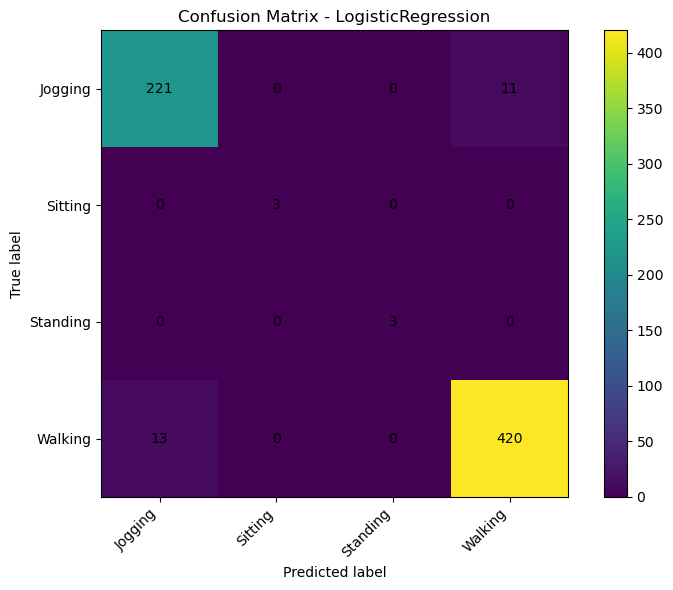

Saved confusion matrix plot to confusion_matrix_best_model.png


In [9]:
best_model_name = max(metrics_summary.items(), key=lambda kv: kv[1]["f1_macro"])[0]
best_model = models[best_model_name]

print("Best model:", best_model_name)
best_y_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, best_y_pred)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, interpolation="nearest")
ax.set_title(f"Confusion Matrix - {best_model_name}")
plt.colorbar(im, ax=ax)

tick_marks = np.arange(len(le.classes_))
ax.set_xticks(tick_marks)
ax.set_xticklabels(le.classes_, rotation=45, ha="right")
ax.set_yticks(tick_marks)
ax.set_yticklabels(le.classes_)
ax.set_ylabel("True label")
ax.set_xlabel("Predicted label")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha="center", va="center")

fig.tight_layout()
plt.show()

fig.savefig("confusion_matrix_best_model.png")
print("Saved confusion matrix plot to confusion_matrix_best_model.png")